In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Make plots show in the notebook
%matplotlib inline

# Set graph style
sns.set(style="whitegrid")


In [ ]:
# Load the Netflix dataset
df = pd.read_csv('netflix_titles.csv')

# Show the first 5 rows
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.shape


(8807, 12)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.dropna(subset=['director', 'cast', 'country'], inplace=True)


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5336 entries, 7 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5336 non-null   object
 1   type          5336 non-null   object
 2   title         5336 non-null   object
 3   director      5336 non-null   object
 4   cast          5336 non-null   object
 5   country       5336 non-null   object
 6   date_added    5336 non-null   object
 7   release_year  5336 non-null   int64 
 8   rating        5335 non-null   object
 9   duration      5333 non-null   object
 10  listed_in     5336 non-null   object
 11  description   5336 non-null   object
dtypes: int64(1), object(11)
memory usage: 541.9+ KB


In [11]:
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)


In [12]:
df.shape

(5336, 12)

In [14]:
# Strip leading/trailing spaces in 'date_added'
df['date_added'] = df['date_added'].str.strip()

# Now safely convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'])


In [15]:
df['date_added'].head()


7    2021-09-24
8    2021-09-24
9    2021-09-24
12   2021-09-23
24   2021-09-21
Name: date_added, dtype: datetime64[ns]

In [16]:
# Create new columns for year, month, and day
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day


In [17]:
df[['date_added', 'year_added', 'month_added', 'day_added']].head()


,date_added,year_added,month_added,day_added
7,2021-09-24,2021,9,24
8,2021-09-24,2021,9,24
9,2021-09-24,2021,9,24
12,2021-09-23,2021,9,23
24,2021-09-21,2021,9,21


In [18]:
# Split genres into a list
df['genres'] = df['listed_in'].apply(lambda x: x.split(', '))


In [19]:
df[['title', 'listed_in', 'genres']].head()


,title,listed_in,genres
7,Sankofa,"Dramas, Independent Movies, International Movies","[Dramas, Independent Movies, International Mov..."
8,The Great British Baking Show,"British TV Shows, Reality TV","[British TV Shows, Reality TV]"
9,The Starling,"Comedies, Dramas","[Comedies, Dramas]"
12,Je Suis Karl,"Dramas, International Movies","[Dramas, International Movies]"
24,Jeans,"Comedies, International Movies, Romantic Movies","[Comedies, International Movies, Romantic Movies]"


C:\Users\anshu\AppData\Local\Temp\ipykernel_1860\2988712330.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2')


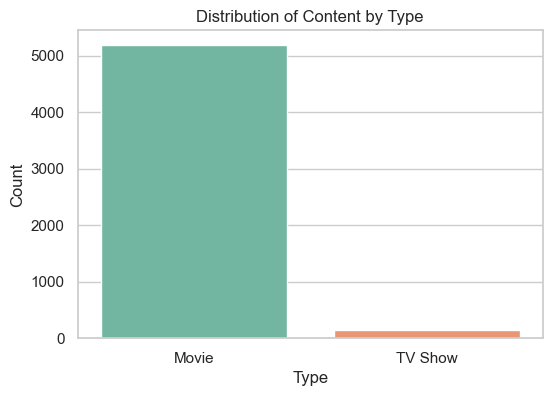

In [20]:
# Count the number of Movies and TV Shows
type_counts = df['type'].value_counts()

# Plot it
plt.figure(figsize=(6, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2')
plt.title('Distribution of Content by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


C:\Users\anshu\AppData\Local\Temp\ipykernel_1860\1672227602.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='mako')


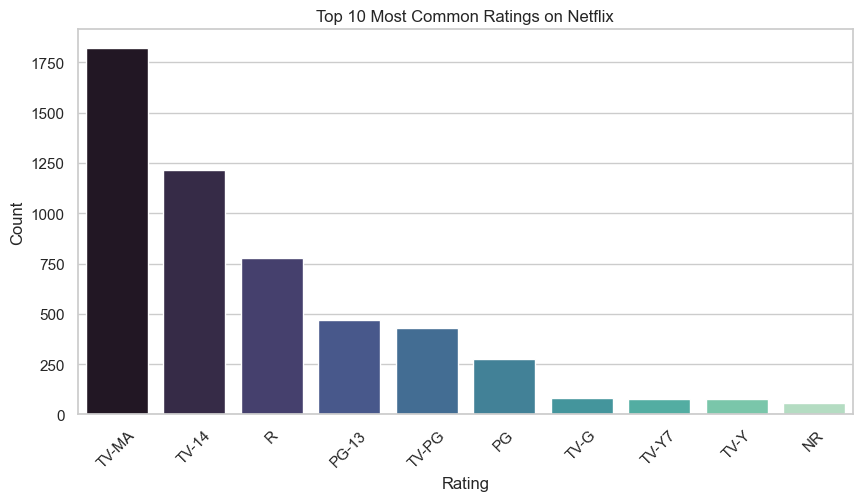

In [21]:
# Count of each rating
rating_counts = df['rating'].value_counts().head(10)  # top 10 ratings

# Bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='mako')
plt.title('Top 10 Most Common Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


C:\Users\anshu\AppData\Local\Temp\ipykernel_1860\904290062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


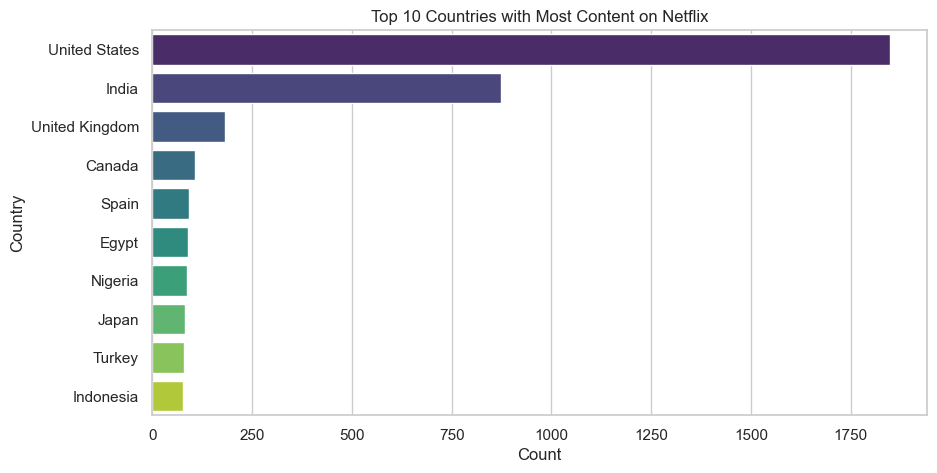

In [23]:
# Top 10 countries by content count
top_countries = df['country'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries with Most Content on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()


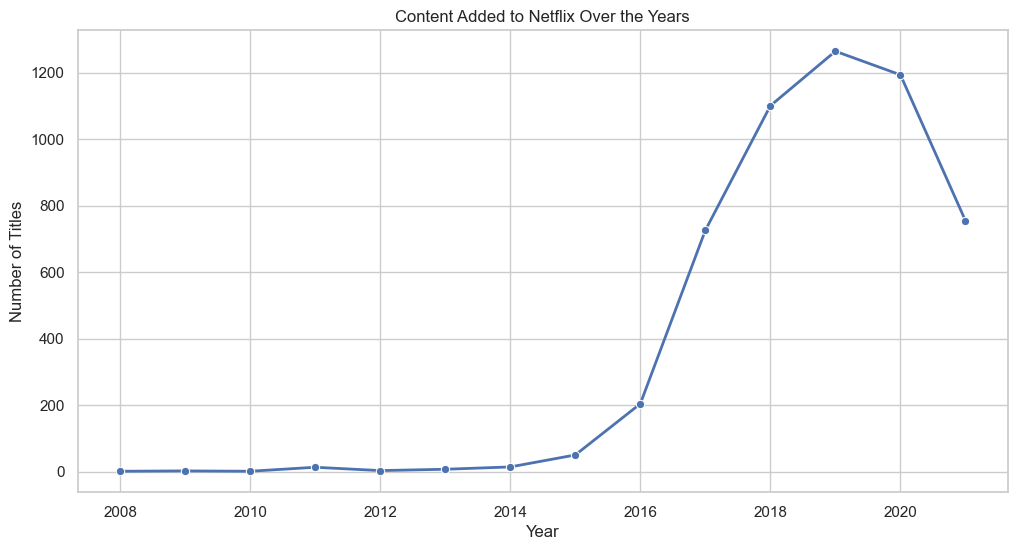

In [24]:
# Number of titles added each year
yearly_counts = df['year_added'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=2)
plt.title('Content Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline
sns.set(style="whitegrid")


In [3]:
df = pd.read_csv('data/netflix_titles.csv')
df.dropna(subset=['director', 'cast', 'country'], inplace=True)
df.drop_duplicates(inplace=True)
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day
df['genres'] = df['listed_in'].apply(lambda x: x.split(', '))


C:\Users\anshu\AppData\Local\Temp\ipykernel_8056\528544201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_genres.values()), y=list(top_genres.keys()), palette='cubehelix')


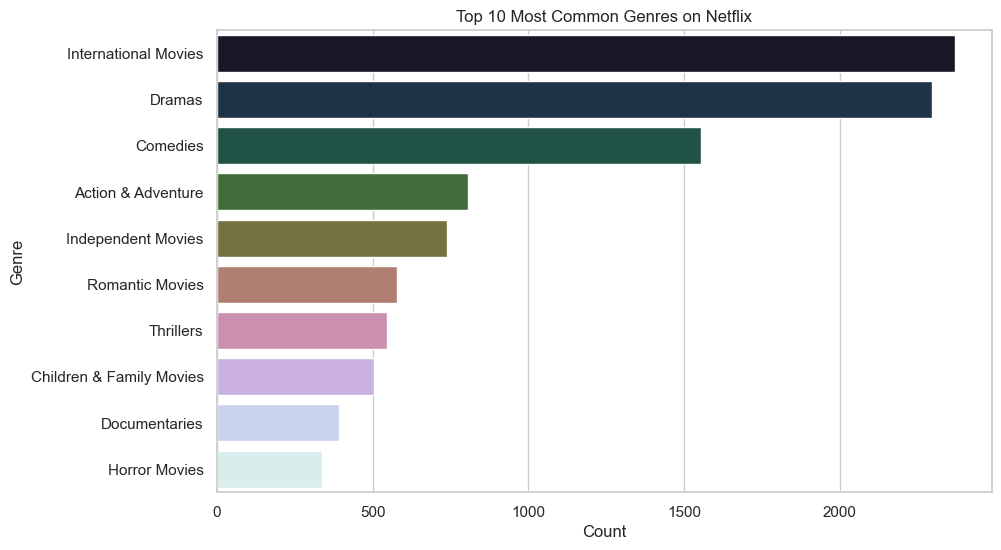

In [4]:
# Flatten the genre list into a single list of genres
all_genres = sum(df['genres'], [])

# Count frequency of each genre
from collections import Counter
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(top_genres.values()), y=list(top_genres.keys()), palette='cubehelix')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


C:\Users\anshu\AppData\Local\Temp\ipykernel_8056\1882724389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='crest')


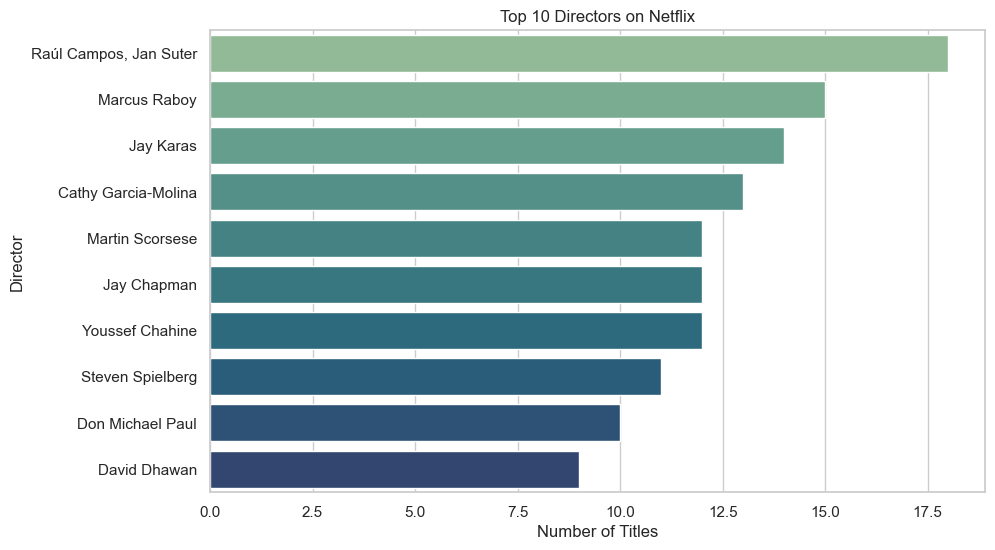

In [5]:
# Count and show top 10 directors
top_directors = df['director'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='crest')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()


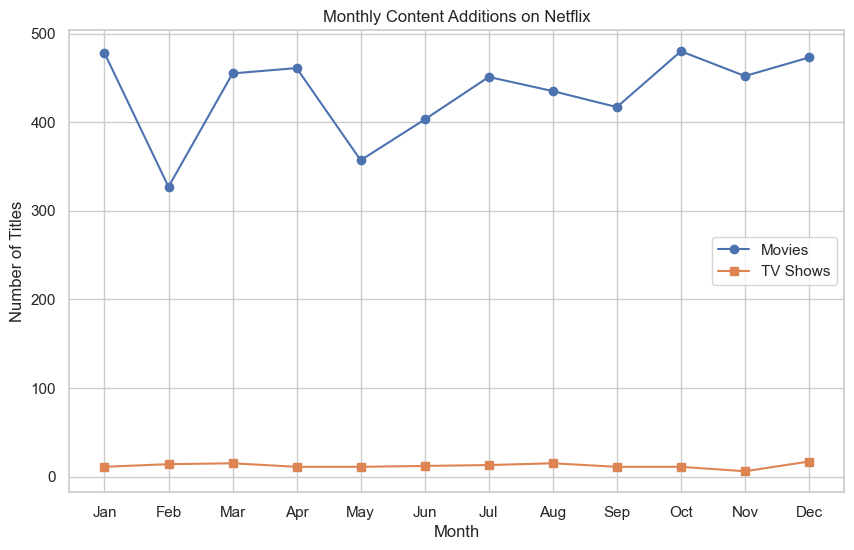

In [6]:
monthly_movie_release = df[df['type'] == 'Movie']['month_added'].value_counts().sort_index()
monthly_series_release = df[df['type'] == 'TV Show']['month_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(monthly_movie_release.index, monthly_movie_release.values, label='Movies', marker='o')
plt.plot(monthly_series_release.index, monthly_series_release.values, label='TV Shows', marker='s')
plt.title("Monthly Content Additions on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True)
plt.show()


## 🧠 Key Insights from Netflix Dataset

- Netflix has more **movies** than TV shows in its catalog.
- **TV-MA** is the most common rating, suggesting a lot of mature content.
- The **United States**, **India**, and **UK** produce the most content.
- Most content was added between **2018 and 2021**, showing Netflix’s global growth.
- Top genres include **Dramas**, **Comedies**, and **Documentaries**.
- Directors like **Rajiv Chilaka** and **Martin Scorsese** have multiple titles.

